In [ ]:
!pip install scanpy
!pip install anndata
!pip3 install igraph
!pip install celltypist
!pip install decoupler
!pip install fa2-modified
!pip install louvain


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.3/169.3 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 43.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 86.0 MB/s eta 0:00:00
  Attempting uninstall: igraph
    Found existing installation: igraph 1.0.0
    Uninstalling igraph-1.0.0:
      Successfully uninstalled i

In [ ]:
#Import core single cell datasets

import scanpy as sc
import anndata as ad
import numpy as np


In [ ]:
!wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE205nnn/GSE205790/suppl/GSE205790_RAW.tar

--2025-10-24 04:08:09--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE205nnn/GSE205790/suppl/GSE205790_RAW.tar
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.13, 130.14.250.31, 130.14.250.7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 98334720 (94M) [application/x-tar]
Saving to: ‘GSE205790_RAW.tar’

GSE205790_RAW.tar   100%[===================>]  93.78M  25.6MB/s    in 3.9s    

2025-10-24 04:08:13 (23.9 MB/s) - ‘GSE205790_RAW.tar’ saved [98334720/98334720]



In [ ]:
!tar -xvf GSE205790_RAW.tar

GSM6229474_C57IMQD_barcodes.tsv.gz
GSM6229474_C57IMQD_features.tsv.gz
GSM6229474_C57IMQD_matrix.mtx.gz
GSM6229475_C57IMQE_barcodes.tsv.gz
GSM6229475_C57IMQE_features.tsv.gz
GSM6229475_C57IMQE_matrix.mtx.gz


In [ ]:

!mkdir -p GSM6229474
!mkdir -p GSM6229475
!mv GSM6229474_* GSM6229474
!mv GSM6229475_* GSM6229475

In [ ]:
!pwd

/content


In [ ]:

!mv /content/GSM6229474/GSM6229474_C57IMQD_barcodes.tsv.gz /content/GSM6229474/barcodes.tsv.gz
!mv /content/GSM6229474/GSM6229474_C57IMQD_features.tsv.gz /content/GSM6229474/features.tsv.gz
!mv /content/GSM6229474/GSM6229474_C57IMQD_matrix.mtx.gz /content/GSM6229474/matrix.mtx.gz


!mv /content/GSM6229475/GSM6229475_C57IMQE_barcodes.tsv.gz /content/GSM6229475/barcodes.tsv.gz
!mv /content/GSM6229475/GSM6229475_C57IMQE_features.tsv.gz /content/GSM6229475/features.tsv.gz
!mv /content/GSM6229475/GSM6229475_C57IMQE_matrix.mtx.gz /content/GSM6229475/matrix.mtx.gz


In [ ]:
psorasis_mtx = sc.read_10x_mtx('GSM6229474/')
psorasis_mtx.var_names_make_unique()

In [ ]:
#psorasis_mtx = sc.read_10x_mtx('GSM6229475/')
#psorasis_mtx.var_names_make_unique()

In [ ]:
psorasis_mtx.shape

(5376, 31053)

In [ ]:
psorasis_mtx.var.head()

,gene_ids,feature_types
Xkr4,ENSMUSG00000051951,Gene Expression
Gm1992,ENSMUSG00000089699,Gene Expression
Gm37381,ENSMUSG00000102343,Gene Expression
Rp1,ENSMUSG00000025900,Gene Expression
Sox17,ENSMUSG00000025902,Gene Expression


In [ ]:
psorasis_mtx.var['MT'] = psorasis_mtx.var_names.str.startswith("MT-")
psorasis_mtx.var['RIBO'] = psorasis_mtx.var_names.str.startswith("RPS", "RPL")
psorasis_mtx.var['HB'] = psorasis_mtx.var_names.str.startswith("^HB[^(P)]")

In [ ]:
sc.pp.calculate_qc_metrics(
    psorasis_mtx, qc_vars=["MT", 'RIBO', 'HB'], inplace=True, log1p=True
)

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (5,4)  # Adjust figure size
plt.rcParams["axes.grid"] = True  # Add grid to plots
plt.rcParams["axes.edgecolor"] = "black" # Set plot border color
plt.rcParams["axes.linewidth"] = 1.5 # Set plot border width
plt.rcParams["axes.facecolor"] = "white" # Set background color
plt.rcParams["axes.labelcolor"] = "black" # Set label color
plt.rcParams["xtick.color"] = "black" # Set x-axis tick color
plt.rcParams["ytick.color"] = "black" # Set y-axis tick color
plt.rcParams["text.color"] = "black" # Set text color

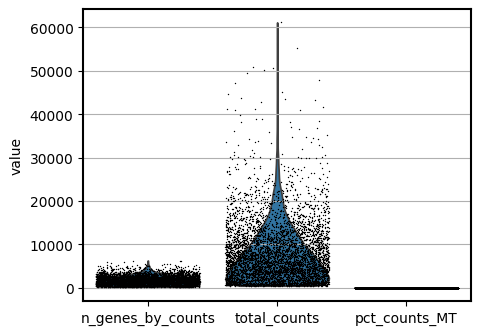

In [ ]:
sc.pl.violin(
    psorasis_mtx,
    ["n_genes_by_counts", 'total_counts', 'pct_counts_MT'],
    jitter=0.4,
    multi_panel=False,
)

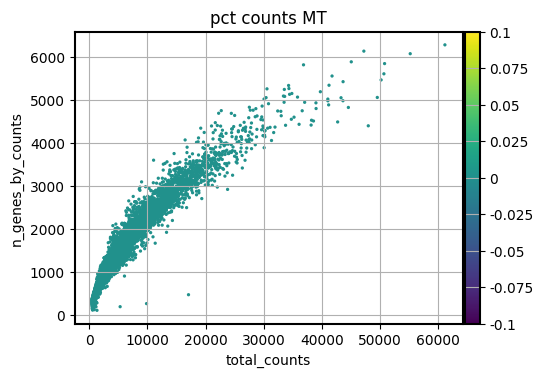

In [ ]:
sc.pl.scatter(psorasis_mtx, "total_counts", "n_genes_by_counts", color="pct_counts_MT")

In [ ]:
sc.pp.scrublet(psorasis_mtx)

In [ ]:
#Normalisation
psorasis_mtx.layers["counts"] = psorasis_mtx.X.copy()
sc.pp.normalize_total(psorasis_mtx)
sc.pp.log1p(psorasis_mtx)

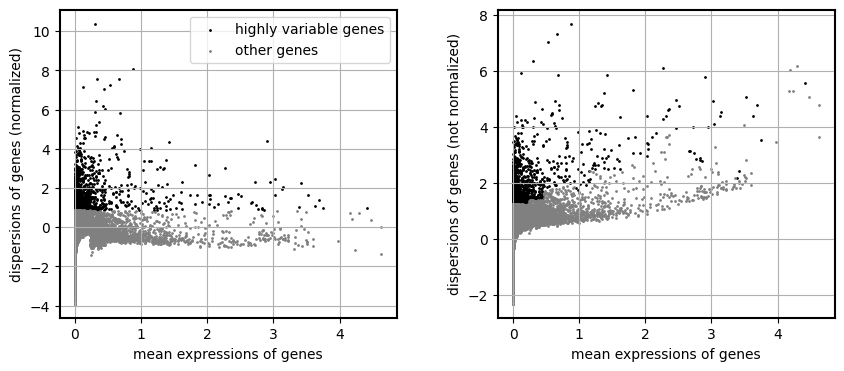

In [ ]:
#Feature selection
sc.pp.highly_variable_genes(psorasis_mtx, n_top_genes=2500)
sc.pl.highly_variable_genes(psorasis_mtx)

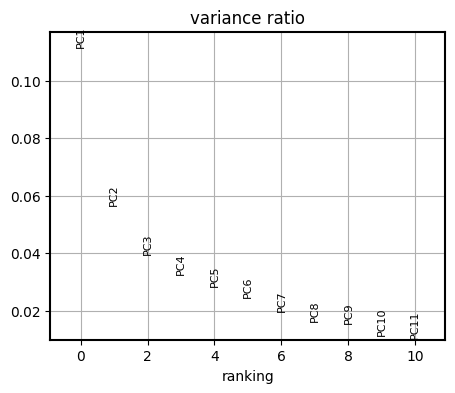

In [ ]:
#Dim Reduction
sc.tl.pca(psorasis_mtx)
sc.pl.pca_variance_ratio(psorasis_mtx, n_pcs=10, log=False)


In [ ]:
il_genes = [gene for gene in psorasis_mtx.var_names[psorasis_mtx.var['highly_variable']] if gene.lower().startswith('il')]
print(il_genes)

['Il17a', 'Il17f', 'Il1r2', 'Il1rl1', 'Il19', 'Il10', 'Il2ra', 'Il1f9', 'Il1rn', 'Il1a', 'Il1b', 'Il6', 'Il5ra', 'Il4i1', 'Il22', 'Il23a', 'Il12b', 'Il4', 'Il13', 'Il3', 'Il7r', 'Il2rb', 'Ildr1']


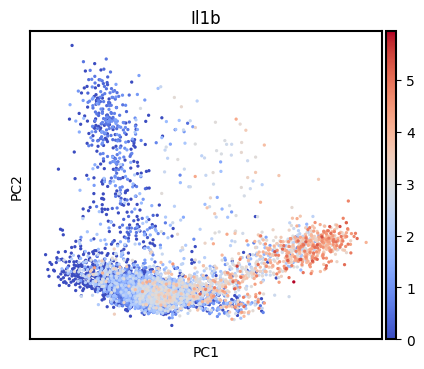

In [ ]:
sc.pl.pca(psorasis_mtx, color="Il1b", cmap="coolwarm")

In [ ]:
sc.pp.neighbors(psorasis_mtx)
sc.tl.umap(psorasis_mtx)

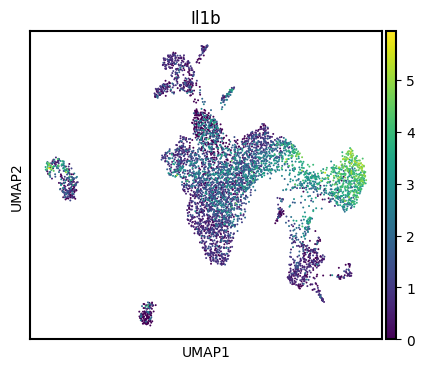

In [ ]:
sc.pl.umap(
    psorasis_mtx,
    color=["Il1b"],
    size=8,
)

In [ ]:
sc.tl.leiden(psorasis_mtx, flavor="igraph", n_iterations=2, key_added="leiden_res0_5", resolution=0.05)

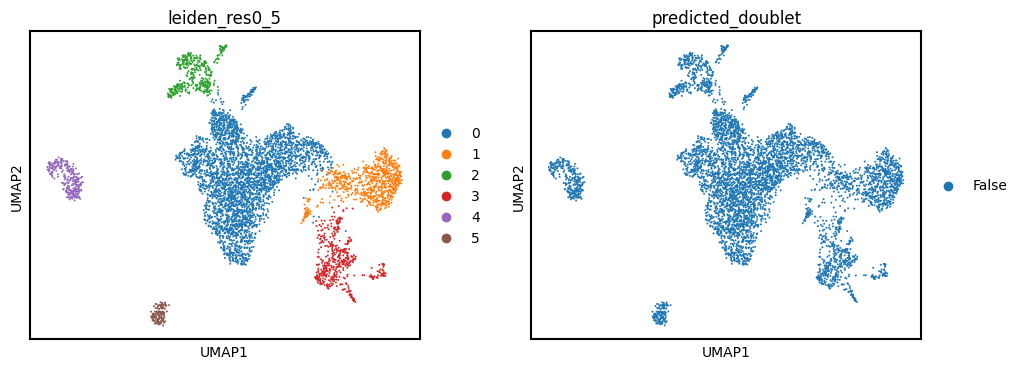

In [ ]:
sc.pl.umap(
    psorasis_mtx,
    color=["leiden_res0_5", 'predicted_doublet'],
    size=8,
)

In [ ]:
import decoupler as dc

In [ ]:
# Query Omnipath and get PanglaoDB
markers = dc.op.resource(name="PanglaoDB", organism="mouse")

# Keep canonical cell type markers alone
markers = markers[markers["mouse"]]

# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]

# Format because dc only accepts cell_type and genesymbol

markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers = markers[["source", "target"]]


markers.head()

,source,target
0,Hepatocytes,A1cf
1,Bergmann glia,A2m
2,Bergmann glia,Mug2
3,Bergmann glia,Mug1
4,Mast cells,A4galt


In [ ]:
psorasis_mtx.var_names

Index(['Xkr4', 'Gm1992', 'Gm37381', 'Rp1', 'Sox17', 'Gm37323', 'Mrpl15',
       'Lypla1', 'Gm37988', 'Tcea1',
       ...
       'AC125149.1', 'AC125149.2', 'AC125149.4', 'AC234645.1', 'AC168977.2',
       'AC168977.1', 'AC149090.1', 'CAAA01118383.1', 'Vmn2r122',
       'CAAA01147332.1'],
      dtype='object', length=31053)

In [ ]:
dc.mt.ulm(data=psorasis_mtx,
          net=markers,
          tmin = 3)

In [ ]:
score = dc.pp.get_obsm(psorasis_mtx, key="score_ulm")

In [ ]:
psorasis_mtx.obsm["score_ulm"].head(1)

,Acinar cells,Adipocyte progenitor cells,Adipocytes,Adrenergic neurons,Airway epithelial cells,Airway goblet cells,Airway smooth muscle cells,Alpha cells,Alveolar macrophages,Anterior pituitary gland cells,...,Thymocytes,Transient cells,Trichocytes,Trigeminal neurons,Trophoblast cells,Trophoblast progenitor cells,Tuft cells,Undefined placental cells,Urothelial cells,Vascular smooth muscle cells
AAACCTGAGAGGTTAT-1,-1.261035,-0.326741,-0.927165,-0.687257,0.076385,-0.53847,-0.532316,1.32622,2.79075,-0.659633,...,1.182331,0.099665,-0.752875,-1.188909,-0.606851,-0.532316,1.734544,-1.019547,-0.813221,-0.752875


In [ ]:
psorasis_mtx.obsm["score_ulm"].columns

Index(['Acinar cells', 'Adipocyte progenitor cells', 'Adipocytes',
       'Adrenergic neurons', 'Airway epithelial cells', 'Airway goblet cells',
       'Airway smooth muscle cells', 'Alpha cells', 'Alveolar macrophages',
       'Anterior pituitary gland cells',
       ...
       'Thymocytes', 'Transient cells', 'Trichocytes', 'Trigeminal neurons',
       'Trophoblast cells', 'Trophoblast progenitor cells', 'Tuft cells',
       'Undefined placental cells', 'Urothelial cells',
       'Vascular smooth muscle cells'],
      dtype='object', length=173)

In [ ]:
#rank genes
psorasis_gene_rank = dc.tl.rankby_group(score, groupby="leiden_res0_5", reference="rest", method="t-test_overestim_var")
psorasis_gene_rank = psorasis_gene_rank[psorasis_gene_rank["stat"] > 0]
psorasis_gene_rank.head(5)

,group,reference,name,stat,meanchange,pval,padj
21,0,rest,Dendritic cells,32.798415,1.733199,2.913403e-216,2.290994e-215
28,0,rest,Proximal tubule cells,30.153956,0.534434,3.369830e-187,2.010278e-186
53,0,rest,Delta cells,23.265208,0.288656,4.040271e-115,1.294383e-114
62,0,rest,Red pulp macrophages,21.392348,0.498373,4.032925e-98,1.107454e-97
77,0,rest,Plasma cells,19.085622,0.427474,4.287698e-79,9.509895e-79


In [ ]:
top_cell_type_per_group = psorasis_gene_rank.groupby('group')['name'].apply(lambda x: x.head(1))
display(top_cell_type_per_group.to_dict())

/tmp/ipython-input-552041747.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_cell_type_per_group = psorasis_gene_rank.groupby('group')['name'].apply(lambda x: x.head(1))


{('0', 21): 'Dendritic cells',
 ('1', 346): 'Neutrophils',
 ('2', 173): 'T memory cells',
 ('3', 519): 'Hepatic stellate cells',
 ('4', 692): 'Basophils',
 ('5', 865): 'Mast cells'}

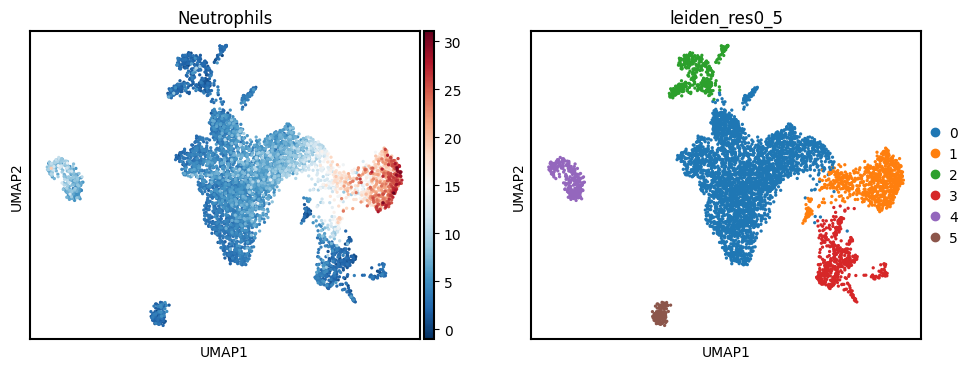

In [ ]:
sc.pl.umap(score, color=["Neutrophils","leiden_res0_5"], cmap="RdBu_r")

In [ ]:
dict_ann = psorasis_gene_rank[psorasis_gene_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()
dict_ann

/tmp/ipython-input-2138141113.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dict_ann = psorasis_gene_rank[psorasis_gene_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()


{'0': 'Dendritic cells',
 '2': 'T memory cells',
 '1': 'Neutrophils',
 '3': 'Hepatic stellate cells',
 '4': 'Basophils',
 '5': 'Mast cells'}

In [ ]:
psorasis_mtx.obs["leiden_res0_5"] = psorasis_mtx.obs["leiden_res0_5"].cat.rename_categories(dict_ann)

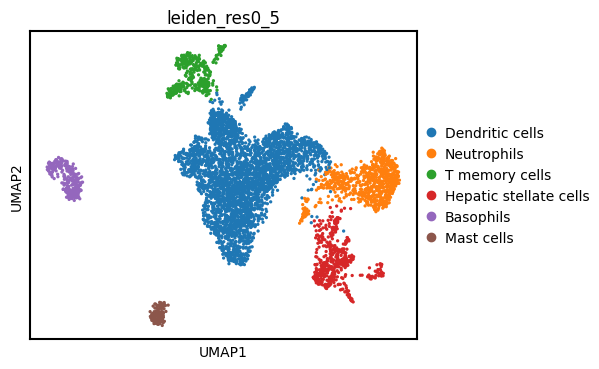

In [ ]:
sc.pl.umap(
    adata=psorasis_mtx,
    color=[ "leiden_res0_5"],
    ncols=1,
)

In [ ]:
#Trajectory analysis
sc.tl.draw_graph(psorasis_mtx)

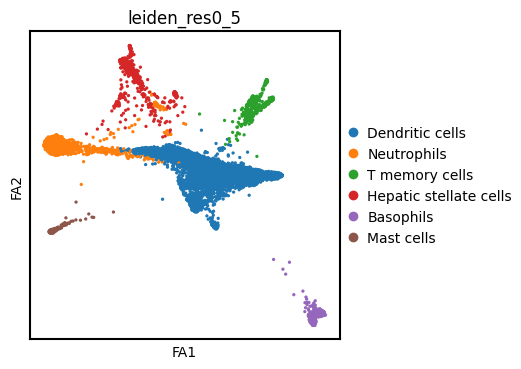

In [ ]:
plt.rcParams["figure.figsize"] = (4,4)
sc.pl.draw_graph(psorasis_mtx, color='leiden_res0_5')

In [ ]:
sc.tl.paga(psorasis_mtx, groups='leiden_res0_5')


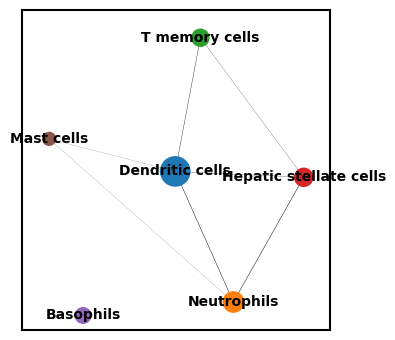

In [ ]:
sc.pl.paga(psorasis_mtx, color=['leiden_res0_5'])

In [ ]:
sc.tl.draw_graph(psorasis_mtx, init_pos='paga')

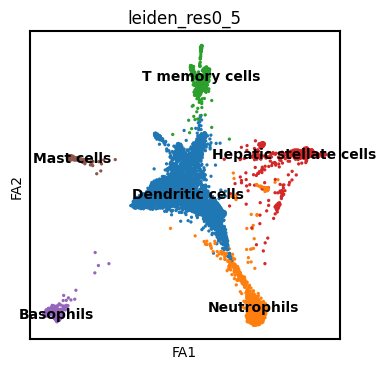

In [ ]:
sc.pl.draw_graph(psorasis_mtx, color='leiden_res0_5', legend_loc='on data')

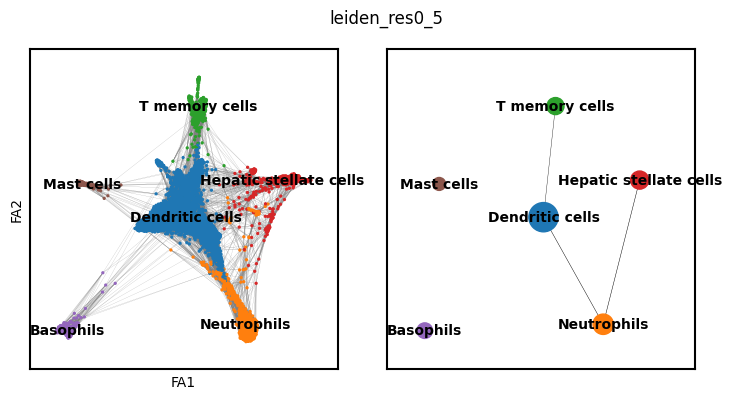

[<Axes: xlabel='FA1', ylabel='FA2'>, <Axes: >]

In [ ]:
sc.pl.paga_compare(psorasis_mtx, threshold=0.03, frameon=True, edges=True)

In [ ]:
psorasis_mtx.uns['iroot'] = np.flatnonzero(psorasis_mtx.obs['leiden_res0_5']  == 'T memory cells')[0]
sc.tl.dpt(psorasis_mtx)

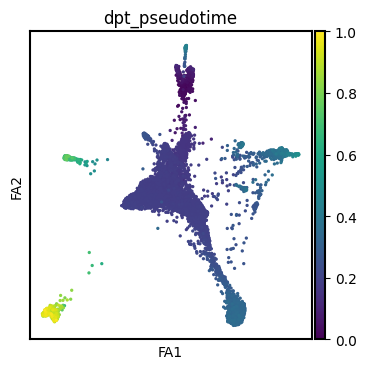

In [ ]:
sc.pl.draw_graph(psorasis_mtx, color=['dpt_pseudotime'], legend_loc='on data')
